In [11]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from kuaizi.display import display_single

In [30]:
data = fits.open('./dolphot_test/mock.fits')[0].data

In [31]:
sky = fits.open('./dolphot_test/mock.sky.fits')[0].data

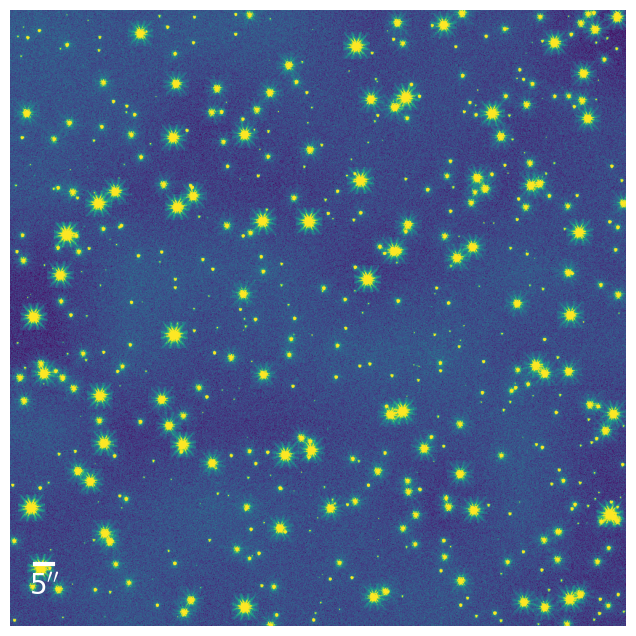

In [32]:
display_single(data - sky);

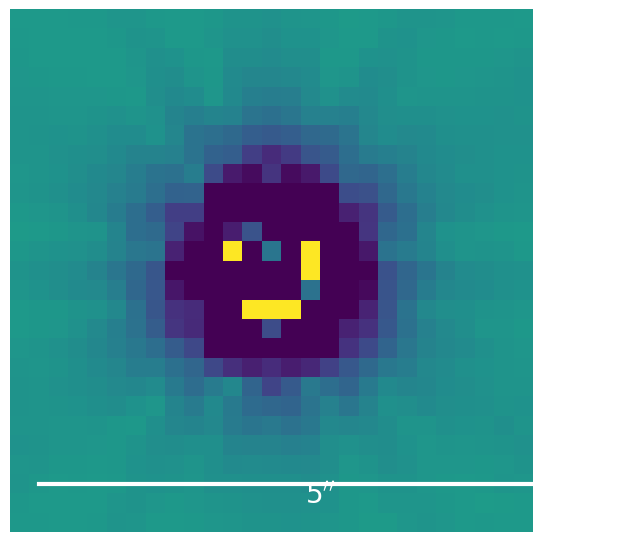

In [33]:
display_single(fits.open('./dolphot_test/out.phot.1.psf.fits')[0].data);

In [113]:
import numpy as np

from astropy.table import Table
from astropy.stats import sigma_clipped_stats
from astropy.modeling.fitting import LevMarLSQFitter

from photutils.psf import EPSFModel, ImagePSF
from photutils.detection import DAOStarFinder
from photutils.datasets import make_model_image
from photutils.psf import PSFPhotometry, SourceGrouper

In [1138]:
def inject_stars(bkg_image, epsf_model, stars):
    """
    Inject stars into a background image.

    Parameters
    ----------
    bkg_image : (ny, nx) ndarray
    epsf_model : EPSFModel (Astropy model)
    stars : astropy.table.Table with columns: x_0, y_0, flux

    Returns
    -------
    img_inj : ndarray
    """
    model_img = make_model_image(
        shape=bkg_image.shape,
        model=epsf_model,
        params_table=stars
    )
    return bkg_image + model_img


def run_photometry(img, epsf_model, fwhm=2.0, threshold_sigma=5.0, error=None):
    """
    Detect and do PSF photometry.

    Returns an Astropy table with fitted x_fit, y_fit, flux_fit (names depend on version).
    """
    mean, med, std = sigma_clipped_stats(img, sigma=4.0)

    finder = DAOStarFinder(fwhm=fwhm, threshold=threshold_sigma * std)
    det = finder(img - med)
    if det is None or len(det) == 0:
        return Table()

    # Photutils expects initial guesses named x_0, y_0 in many PSF classes
    init = Table()
    init["x_0"] = det["xcentroid"]
    init["y_0"] = det["ycentroid"]
    init["flux"] = np.maximum(det["flux"], 1.0)

    fitter = LevMarLSQFitter()
    grouper = SourceGrouper(min_separation=2.0)  # in pixels; tune for crowding
    phot = PSFPhotometry(
        psf_model=epsf_model,
        fit_shape=(15, 15),   # odd size; tune to include PSF core/wings
        finder=None,          # we already ran a finder
        grouper=grouper,
        fitter=fitter,
        localbkg_estimator=None,  # use if background varies strongly
    )
    res = phot(img, init_params=init, error=error)
    return res

In [415]:
def match_injected_to_recovered(stars_in, stars_out, rmatch=1.0):
    """
    Simple nearest-neighbor match within rmatch (pixels).

    Returns: recovered_mask (len = N_in), plus matched output indices (or -1).
    """
    if stars_out is None or len(stars_out) == 0:
        return np.zeros(len(stars_in), dtype=bool), -np.ones(len(stars_in), dtype=int)

    # Try to find plausible output column names across versions
    xout_candidates = ["x_fit", "x_0", "x"]
    yout_candidates = ["y_fit", "y_0", "y"]
    fout_candidates = ["flux_fit", "flux_0", "flux"]

    def first_col(tbl, names):
        for n in names:
            if n in tbl.colnames:
                return np.asarray(tbl[n])
        raise KeyError(f"None of {names} found in output table columns {tbl.colnames}")

    x_out = first_col(stars_out, xout_candidates)
    y_out = first_col(stars_out, yout_candidates)
    f_out = first_col(stars_out, fout_candidates)

    x_in = np.asarray(stars_in["x_0"])
    y_in = np.asarray(stars_in["y_0"])

    recovered = np.zeros(len(stars_in), dtype=bool)
    match_idx = -np.ones(len(stars_in), dtype=int)

    for i in range(len(stars_in)):
        dx = x_out - x_in[i]
        dy = y_out - y_in[i]
        r = np.hypot(dx, dy)
        j = np.argmin(r)
        if r[j] <= rmatch:
            recovered[i] = True
            match_idx[i] = j

    return recovered, match_idx

In [ ]:
import galsim
import romanisim
import romanisim.parameters
from romanisim.l3 import l3_psf
roman_psf = l3_psf('F158', 0.1078577405, stpsf=True, fov_arcsec=5)
# psf = l3_psf('F158', 0.11, stpsf=True, fov_arcsec=5)

scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

img = roman_psf.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
psf_img = img.array / img.array.sum()

In [228]:
from astropy.modeling.bounding_box import ModelBoundingBox

psf_img = psf_img.astype(float)
ny, nx = psf_img.shape
assert ny == nx, "PSF stamp should be square"
assert nx % 2 == 1, "Strongly recommended: odd-sized PSF stamp"
half = (nx - 1) / 2  # in pixels
# bbox = ModelBoundingBox(
#     x_bounds=(-half, half),
#     y_bounds=(-half, half),
# )

epsf = EPSFModel(
    psf_img,
    oversampling=1,
    # bbox=bbox,
    origin=(0.0, 0.0),
    normalize=False,  # already normalized above
)

epsf = ImagePSF(psf_img)

In [375]:
hdu = fits.open('./sky_jaguar_test/F158_642s.fits')
w = WCS(hdu[0].header)
bkg_img = hdu[0].data
img = bkg_img

fwhm = 2
threshold_sigma = 4

In [376]:
mean, med, std = sigma_clipped_stats(img, sigma=3.0)

finder = DAOStarFinder(fwhm=fwhm, threshold=threshold_sigma * std)
det = finder(img - med)

In [377]:
from kuaizi.display import draw_circles

In [408]:
-2.5 * np.log10(std * 5) + zp

np.float32(27.57277)

In [ ]:
res = run_photometry(img, epsf)

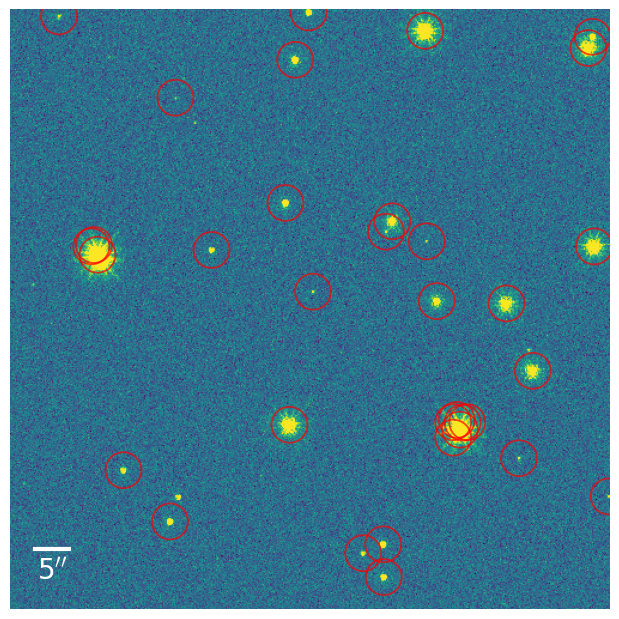

In [414]:
draw_circles(img, res, colnames=['x_fit', 'y_fit']);
# draw_circles(img, truth[14:15], colnames=['x', 'y']);

In [379]:
306.18664 - 834 * 0.31706

41.7586

In [380]:
-2.5 * np.log10(41.7586) + zp

np.float64(21.21336303720031)

In [381]:
truth = Table.read('./sky_jaguar_test/temp/sky_table.ecsv')

In [382]:
truth['F158'] = -2.5 * np.log10(truth['F158'])

In [383]:
truth['x'], truth['y'] = w.all_world2pix(truth['ra'], truth['dec'], 0)

In [384]:
truth['ra', 'dec', 'x', 'y', 'F158'][13:14]

ra,dec,x,y,F158
float64,float64,float64,float64,float64
150.10427224719348,2.2768051045054585,229.47158142623877,338.5306974382135,21.126


In [385]:
# Photutils expects initial guesses named x_0, y_0 in many PSF classes
init = Table()
init["x_0"] = det["xcentroid"]
init["y_0"] = det["ycentroid"]
# A crude starting flux guess; you can do better (aperture sum, etc.)
init["flux"] = np.maximum(det["flux"], 1.0)
fitter = LevMarLSQFitter()

grouper = SourceGrouper(min_separation=2.0)  # in pixels; tune for crowding
psfphot = PSFPhotometry(
    psf_model=epsf,
    fit_shape=(25, 25),   # odd size; tune to include PSF core/wings
    finder=None,          # we already ran a finder
    grouper=grouper,
    fitter=fitter,
    aperture_radius=5,
    localbkg_estimator=None,  # use if background varies strongly
)
res = psfphot(img, init_params=init)
res['ra'], res['dec'] = w.all_pix2world(res['x_fit'], res['y_fit'], 0)

In [386]:
def match_truth_to_fit_sky(truth, res, *, max_sep=0.3*u.arcsec):
    """
    Match each truth source to the nearest fitted source in (RA, Dec).

    Parameters
    ----------
    truth : astropy.table.Table
        Must contain 'ra','dec' (deg), plus typically 'x','y','F158' (mag).
    res : astropy.table.Table
        Must contain 'ra','dec' (deg), and typically 'x_fit','y_fit','flux_fit' (or similar).
    max_sep : astropy.units.Quantity
        Maximum allowed separation for a match.

    Returns
    -------
    out : astropy.table.Table
        A truth-indexed table containing match info and (if possible) photometric residuals.
    """
    # SkyCoord objects
    c_truth = SkyCoord(ra=np.asarray(truth["ra"])*u.deg,
                       dec=np.asarray(truth["dec"])*u.deg)
    c_fit   = SkyCoord(ra=np.asarray(res["ra"])*u.deg,
                       dec=np.asarray(res["dec"])*u.deg)

    # Nearest-neighbor match: for each truth entry, find nearest fitted entry
    idx, sep2d, _ = c_truth.match_to_catalog_sky(c_fit)

    matched = sep2d <= max_sep

    out = truth.copy()
    out["match_idx"] = idx
    out["sep_arcsec"] = sep2d.to_value(u.arcsec)
    out["matched"] = matched

    # Bring in fitted columns for matched objects (fill unmatched with NaN)
    # Robustly pick position/flux column names across photutils versions
    def pick_col(tbl, names):
        for n in names:
            if n in tbl.colnames:
                return n
        return None

    xcol = pick_col(res, ["x_fit", "x_0", "x"])
    ycol = pick_col(res, ["y_fit", "y_0", "y"])
    fcol = pick_col(res, ["flux_fit", "flux_0", "flux"])

    out["x_fit"] = np.nan
    out["y_fit"] = np.nan
    out["flux_fit"] = np.nan

    if xcol is not None:
        out["x_fit"][matched] = np.asarray(res[xcol])[idx[matched]]
    if ycol is not None:
        out["y_fit"][matched] = np.asarray(res[ycol])[idx[matched]]
    if fcol is not None:
        out["flux_fit"][matched] = np.asarray(res[fcol])[idx[matched]]

    # Astrometric residuals in pixel space (if truth has x,y)
    if "x" in out.colnames and "y" in out.colnames and xcol is not None and ycol is not None:
        out["dx_pix"] = np.nan
        out["dy_pix"] = np.nan
        out["dx_pix"][matched] = out["x_fit"][matched] - np.asarray(out["x"])[matched]
        out["dy_pix"][matched] = out["y_fit"][matched] - np.asarray(out["y"])[matched]

    # Photometric residuals:
    # If truth has a magnitude (e.g. F158), convert fitted flux to an "instrumental magnitude"
    # m_inst = -2.5 log10(flux).  This gives Δm up to an additive constant (zeropoint cancels for comparisons).
    if "F158" in out.colnames and fcol is not None:
        out["m_fit_inst"] = np.nan
        out["dmag_inst"] = np.nan

        ok = matched & np.isfinite(out["flux_fit"]) & (out["flux_fit"] > 0)
        out["m_fit_inst"][ok] = -2.5 * np.log10(out["flux_fit"][ok])
        # dmag up to a constant zeropoint; if your truth 'F158' is an apparent mag,
        # you'll want to include the zeropoint to put m_fit on the same system (see below).
        out["dmag_inst"][ok] = out["m_fit_inst"][ok] - np.asarray(out["F158"])[ok]

    return out


In [387]:
temp = match_truth_to_fit_sky(truth, res)

In [388]:
-2.5 * np.log10(46.51898468341157) + zp

np.float64(21.096152294094143)

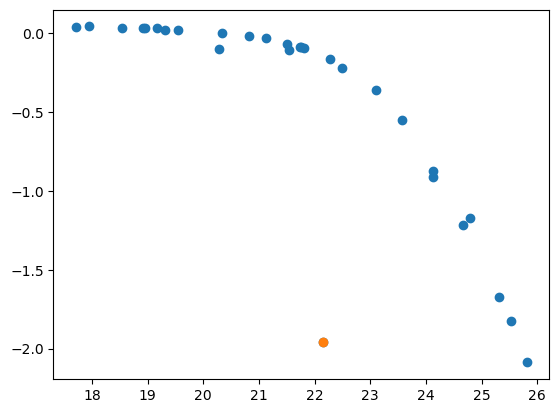

In [391]:
delta = -2.5 * np.log10(temp['flux_fit']) + zp - temp['F158']
plt.scatter(temp['F158'], delta)
plt.scatter(temp['F158'][16], delta[16])

In [352]:
# resid = psfphot.make_residual_image(img)
# display_single(resid);

In [359]:
res['ra'], res['dec'] = w.all_pix2world(res['x_fit'], res['y_fit'], 1)

In [360]:
coords_res = SkyCoord(res['ra'], res['dec'], unit='deg')
coords_truth = SkyCoord(truth['ra'], truth['dec'], unit='deg')

In [361]:
np.min(coords_truth[13].separation(coords_res))

<Angle 5.02320761e-07 deg>

In [357]:
coords_res[35]

<SkyCoord (ICRS): (ra, dec) in deg
    (150.10427275, 2.27680516)>

In [315]:
zp = 25.265227862373404

In [346]:
-2.5 * np.log10(46.51898468341157) + zp

np.float64(21.096152294094143)

In [424]:
# -----------------------------------
# Define an artificial-star experiment
# -----------------------------------
rng = np.random.default_rng(123)

ny, nx = bkg_img.shape
n_inj = 200

# Random positions (avoid edges by a margin ~ fit box half-size)
margin = 10
x = rng.uniform(margin, nx - margin, n_inj)
y = rng.uniform(margin, ny - margin, n_inj)

# Choose magnitudes and convert to flux. You can swap in your own zeropoint.
# Here: flux spans a decade for demo.
flux = 10 ** rng.uniform(0.0, 2.0, n_inj)

stars_in = Table()
stars_in["x_0"] = x
stars_in["y_0"] = y
stars_in["flux"] = flux

# Inject
img_inj = inject_stars(bkg_img, epsf, stars_in)

# Recover
stars_out = run_photometry(img_inj, epsf, fwhm=2.0, threshold_sigma=5.0)

# Match + completeness
recovered, match_idx = match_injected_to_recovered(stars_in, stars_out, rmatch=1.0)
completeness = recovered.mean()

print(f"Injected: {len(stars_in)}  Recovered: {recovered.sum()}  "
      f"Completeness: {completeness:.3f}")

In [1014]:
# hdu = fits.open('./sky_jaguar_test/F158_642s.fits')
hdu = fits.open('./sky_jaguar_test/F106_642s.fits')
w = WCS(hdu[0].header)
bkg_img = hdu[0].data.astype(float)

import sep
bkg_model = sep.Background(bkg_img, bh=128, bw=128)
bkg_img -= bkg_model.globalback
# img = bkg_img

In [ ]:
import galsim
import romanisim
import romanisim.parameters
from romanisim.l3 import l3_psf
roman_psf_F158 = l3_psf('F158', 1, stpsf=True, fov_arcsec=5)
roman_psf_F106 = l3_psf('F106', 1, stpsf=True, fov_arcsec=5)
# psf = l3_psf('F158', 0.11, stpsf=True, fov_arcsec=5)

In [1109]:
romanisim.parameters.pixel_scale

0.11

In [1110]:
1 / np.sum(psf_img**2)

np.float32(9.298825)

In [1168]:
import numpy as np
from astropy.table import Table

def one_star_trial(bkg_img, epsf, *, x0, y0, flux,
                   fwhm=2.0, threshold_sigma=5.0, rmatch=1.0):
    """
    Inject one star into bkg_img and test if it is recovered.

    Returns
    -------
    recovered : bool
    match_sep_pix : float (nan if not recovered)
    flux_fit : float (nan if not recovered)
    """
    # truth table for one star
    stars_in = Table()
    stars_in["x_0"] = [float(x0)]
    stars_in["y_0"] = [float(y0)]
    stars_in["flux"] = [float(flux)]

    img_inj = inject_stars(bkg_img, epsf, stars_in)
    
    stars_out = run_photometry(img_inj, epsf, fwhm=fwhm, threshold_sigma=threshold_sigma, 
                               error=np.std(bkg_img) * np.ones_like(img_inj))
    if len(stars_out) == 0:
        draw_circles(convolve_fft(img_inj, psf_img), stars_in, colnames=['x_0', 'y_0'], color='cyan')
    else:
        draw_circles(convolve_fft(img_inj, psf_img), stars_out, colnames=['x_fit', 'y_fit'])

    if stars_out is None or len(stars_out) == 0:
        return False, np.nan, np.nan

    recovered, match_idx = match_injected_to_recovered(stars_in, stars_out, rmatch=rmatch)
    print(match_idx)
    if not recovered[0]:
        return False, np.nan, np.nan

    j = match_idx[0]

    # robustly get fitted columns
    def getcol(tbl, names):
        for n in names:
            if n in tbl.colnames:
                return np.asarray(tbl[n])
        raise KeyError(f"None of {names} in {tbl.colnames}")

    xfit = getcol(stars_out, ["x_fit", "x_0", "x"])[j]
    yfit = getcol(stars_out, ["y_fit", "y_0", "y"])[j]
    ffit = getcol(stars_out, ["flux_fit", "flux_0", "flux"])[j]
    ffit_err = getcol(stars_out, ["flux_err"])[j]

    sep = float(np.hypot(xfit - x0, yfit - y0))
    print("SNR", float(ffit / ffit_err))
    # return True, sep, float(ffit)#, float(ffit / ffit_err)
    return img_inj, stars_out

In [1114]:
np.sum(psf_img**2)

np.float32(0.107540466)

In [1124]:
scale = romanisim.parameters.pixel_scale
nx = ny = (int(5 / scale) // 2) * 2 + 1

In [1169]:
psf_imgs = {}

img = roman_psf_F158.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
psf_imgs['F158'] = img.array / img.array.sum()

img = roman_psf_F106.drawImage(nx=nx, ny=ny, scale=scale, method="auto")  # auto chooses real/k-space wisely
psf_imgs['F106'] = img.array / img.array.sum()

In [1140]:
import photutils

In [1141]:
photutils.psf.decode_psf_flags(24)

['no_convergence', 'no_covariance']

In [1136]:
stars_in

id,group_id,group_size,local_bkg,x_init,y_init,flux_init,x_fit,y_fit,flux_fit,x_err,y_err,flux_err,npixfit,qfit,cfit,reduced_chi2,flags
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64
1,1,1,0.0,186.7420720536661,145.28065035611877,1.0,187.05941475162055,145.82821946857212,0.26277159737253075,0.28689972403779485,0.2632216378069678,0.07501884696638061,625,46.7285201792745,-0.055643340199401176,1.0597231247455439,0
2,2,1,0.0,190.98487519378082,319.6008108074514,1.0,191.1206495992829,319.75082745835135,0.2751052003709968,0.2628844032401284,0.235927056424241,0.07681477026965726,625,45.375550076628194,0.07264748817926565,1.116498336867671,0
3,3,1,0.0,5.833041290281656,373.2732103474595,1.0,6.029305560960488,373.00077041172966,0.22255401861482224,0.3401978500980835,0.3467750392568604,0.07299354993788384,475,41.34681976631854,0.12956501464029418,1.0453188050880122,1
4,4,1,0.0,150.10117163563578,400.4516373425312,1.0,149.9356666314601,400.1662522412987,0.7098915744090804,nan,nan,nan,625,16.324676145294614,-0.03253796106704169,0.9512111146523524,24
5,5,1,0.0,468.4254560524178,410.19823195074474,1.0,468.18098097072345,410.042921500961,0.24653098155327338,0.2635326448027545,0.3125341342167207,0.07581578430772655,625,49.60930763029028,0.08341769729711962,1.0519652906445778,0
6,6,1,0.0,40.042635292834305,432.26549281906324,1.0,40.036230303327514,431.9325289773671,0.23500109400266112,0.32196823551261555,0.3257530708424297,0.07318487795592517,625,49.623350532657945,0.09694573742690485,0.9646421938074533,0
7,7,1,0.0,423.43474969689606,442.48036510391466,1.0,423.7599493749211,442.80005167996126,0.33002787562743136,0.19787876021509984,0.21271704217904913,0.07736752462718806,625,36.43001185305673,0.002132950159683274,1.0605178011599454,0
8,8,1,0.0,82.27042201124434,453.6690269574118,1.0,82.70258437556996,453.9006482819745,0.27919432134965416,0.21437299321137845,0.2805280335804739,0.07677004130165105,625,41.39080512667097,0.03636660211304751,0.9417422726275041,0


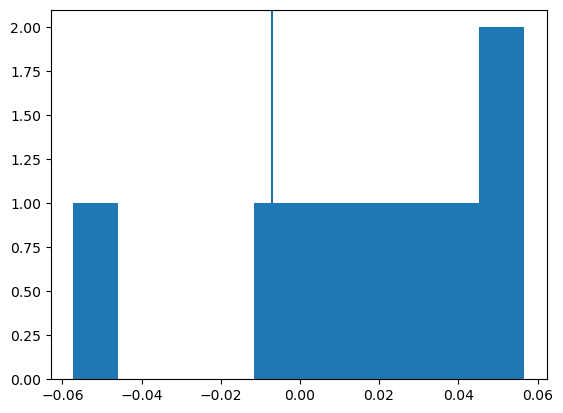

In [1182]:
plt.hist(stars_in['cfit'])
plt.axvline(stars_in['cfit'][1])

In [ ]:
cfit : a quality-of-fit metric defined as the fit residual (data - model) in the initial central pixel value divided by the fit flux. NaN values indicate that the central pixel was masked. Large positive values indicate sources that are sharper than the PSF model (e.g., cosmic ray, hot pixel, etc.). Large negative values indicate sources that are broader than the PSF model

[1]
SNR 6.658554996261526


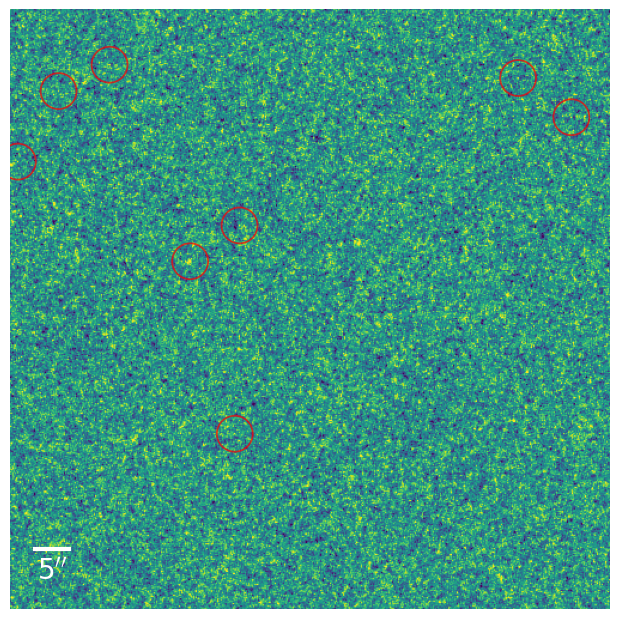

In [1177]:
# img_inj, stars_in = one_star_trial(bkg_img, ImagePSF(psf_imgs['F106']), x0=150, y0=400, flux=10**(-0.4 * (26.5 - zp)), fwhm=1.2, threshold_sigma=4)
img_inj, stars_in = one_star_trial(bkg_img, ImagePSF(psf_imgs['F106']), x0=150, y0=290, flux=10**(-0.4 * (26.5 - zp)), fwhm=1.2, threshold_sigma=4)

In [927]:
import sep

In [928]:
bkg = sep.Background(img_inj)
temp = sep.extract(img_inj, 2, err=bkg.globalrms)#, filter_kernel=psf_img, filter_type='conv')
len(temp)

1

In [1163]:
from astropy.convolution import convolve_fft

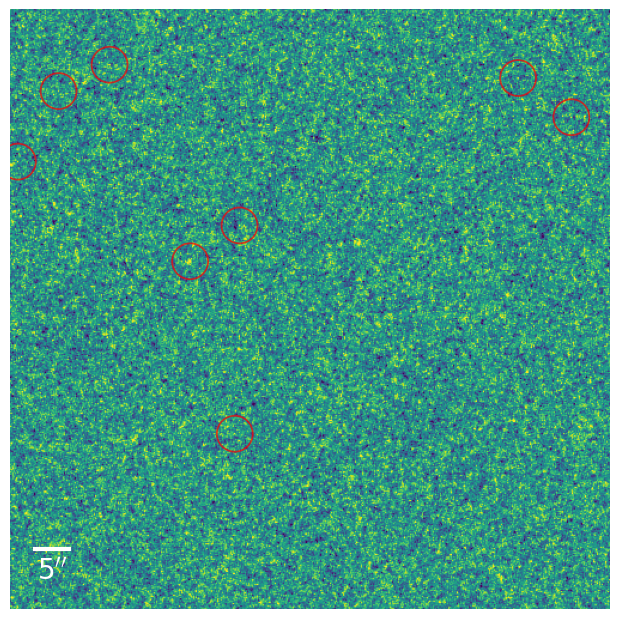

In [1167]:
# draw_circles(img_inj, stars_in, colnames=['x_0', 'y_0'])
# draw_circles(img_inj, stars_in[:], colnames=['x_fit', 'y_fit'])
draw_circles(convolve_fft(img_inj, psf_img), stars_in, colnames=['x_fit', 'y_fit'])
# draw_circles(img_inj, temp, colnames=['x', 'y'])

In [911]:
-2.5 * np.log10(5) + zp

np.float64(23.517802851533357)

In [933]:
def completeness_vs_mag(
    bkg_img, epsf, *,
    mags,               # array of magnitudes to test (bin centers)
    ZP,                 # magnitude zeropoint: mag = -2.5log10(flux) + ZP
    n_trials_per_mag=200,
    margin=10,
    fwhm=1.0,
    threshold_sigma=5.0,
    rmatch=1.0,
    rng=None,
):
    """
    One-star artificial-star test. Returns a table with completeness vs magnitude.

    Assumes flux = 10**(-0.4*(mag - ZP)).
    """
    if rng is None:
        rng = np.random.default_rng(123)

    ny, nx = bkg_img.shape

    # output accumulators
    out = Table()
    out["mag"] = np.asarray(mags, dtype=float)
    out["n_inj"] = np.zeros(len(mags), dtype=int)
    out["n_rec"] = np.zeros(len(mags), dtype=int)
    out["comp"] = np.nan
    out["fratio_all"] = [None] * len(out)
    out["median_sep_pix"] = np.nan
    out["median_flux_ratio"] = np.nan  # f_fit / f_true, for recovered only

    for k, mag in enumerate(out["mag"]):
        flux_true = 10 ** (-0.4 * (mag - ZP))

        seps = []
        fratio = []
        nrec = 0

        for _ in range(n_trials_per_mag):
            x0 = rng.uniform(margin, nx - margin)
            y0 = rng.uniform(margin, ny - margin)

            rec, sep, ffit = one_star_trial(
                bkg_img, epsf, x0=x0, y0=y0, flux=flux_true,
                fwhm=fwhm, threshold_sigma=threshold_sigma, rmatch=rmatch
            )

            if rec:
                nrec += 1
                seps.append(sep)
                fratio.append(ffit / flux_true)

        out["n_inj"][k] = n_trials_per_mag
        out["n_rec"][k] = nrec
        out["comp"][k] = nrec / n_trials_per_mag
        out["fratio_all"][k] = np.array(fratio)
        
        if nrec > 0:
            out["median_sep_pix"][k] = float(np.median(seps))
            out["median_flux_ratio"][k] = float(np.median(fratio))

    return out


In [934]:
zp

25.265227862373404

In [946]:
mags = np.arange(24.0, 27.5, 0.25)   # choose your range
ZP = 25.265

epsf = ImagePSF(psf_img, oversampling=1)
tab = completeness_vs_mag(
    bkg_img, epsf,
    mags=mags, ZP=ZP,
    n_trials_per_mag=100,
    margin=30,
    fwhm=1.25,
    threshold_sigma=3.5,
    rmatch=2.0,
)

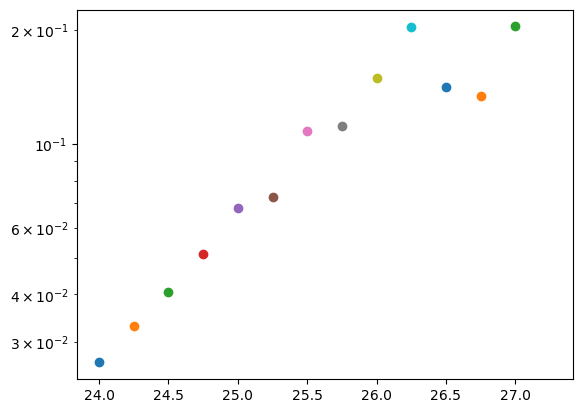

In [951]:
for i in range(len(tab)):
    # mag = tab[i]['mag']
    delta_mag = -2.5 * np.log10(tab[i]['fratio_all'])
    mag = [tab[i]['mag']] * len(delta_mag)
    stds = np.std(delta_mag)
    # plt.scatter(mag, delta_mag, s=1, color='k')
    plt.scatter(tab[i]['mag'], stds)

plt.yscale('log')

In [980]:
from astropy.table import Table
import numpy as np

def run_ast_trials(bkg_img, epsf, mags, ZP, *, n_trials_per_mag=200,
                   margin=10, fwhm=2.0, threshold_sigma=5.0, rmatch=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng(123)
    ny, nx = bkg_img.shape

    rows = []
    delta_mag = np.diff(mags)[0]
    for mag in mags:
        for _ in range(n_trials_per_mag):
            mag = rng.uniform(mag - delta_mag / 2, mag + delta_mag / 2)
            _flux = 10 ** (-0.4 * (mag - ZP))
            
            x0 = rng.uniform(margin, nx - margin)
            y0 = rng.uniform(margin, ny - margin)

            rec, sep, ffit = one_star_trial(
                bkg_img, epsf, x0=x0, y0=y0, flux=_flux,
                fwhm=fwhm, threshold_sigma=threshold_sigma, rmatch=rmatch
            )

            if rec and np.isfinite(ffit) and (ffit > 0):
                mag_out = -2.5*np.log10(ffit) + ZP
            else:
                mag_out = np.nan

            rows.append((mag, mag_out, rec, x0, y0, sep))

    t = Table(rows=rows, names=["mag_in", "mag_out", "recovered", "x", "y", "sep_pix"])
    t["dmag"] = t["mag_out"] - t["mag_in"]
    return t


In [1005]:
mags = np.arange(25.0, 27, 0.25)   # choose your range
ZP = 25.265

epsf = ImagePSF(psf_img, oversampling=1)
tab = run_ast_trials(
    bkg_img, epsf,
    mags=mags, ZP=ZP,
    n_trials_per_mag=100,
    margin=30,
    fwhm=1.25,
    threshold_sigma=3.5,
    rmatch=2.0,
)

In [1006]:
tab

mag_in,mag_out,recovered,x,y,sep_pix,dmag
float64,float64,bool,float64,float64,float64,float64
25.045587965812036,25.029535211236983,True,53.7350692917802,127.17870389272161,0.11227648150396452,-0.016052754575053285
24.966680918486702,24.9471689998975,True,107.57450237849838,388.1336774351962,0.014118515469312648,-0.019511918589202537
25.072517167993468,25.063043085867417,True,151.96930942852384,391.51176166251395,0.02323924461242507,-0.009474082126050831
25.169990341271266,25.254167037449882,True,256.2199707562236,138.02938907133924,0.08502281195320519,0.08417669617861634
25.251050740295618,25.17541089196664,True,124.26946684841711,356.98697003550694,0.15411041893082988,-0.0756398483289793
25.28353579144304,25.23414868513571,True,438.98660100959864,132.2715111754307,0.10475704500093623,-0.049387106307328565
25.35831707359806,25.36437926161273,True,258.51078125204697,132.11603054432675,0.04722160455304886,0.006062188014670511
25.274793071908245,25.275312495932177,True,249.52493510752709,286.9815665113561,0.04111947445629394,0.0005194240239312364
25.195877568765365,25.24169394459726,True,36.56865829126242,237.76975394069322,0.0470159838293231,0.04581637583189391


In [1007]:
def _binned_stat(x, y, bins, stat="median"):
    x = np.asarray(x)
    y = np.asarray(y)
    idx = np.digitize(x, bins) - 1
    xc, ys = [], []
    for i in range(len(bins)-1):
        m = (idx == i) & np.isfinite(y)
        if np.sum(m) == 0:
            xc.append(0.5*(bins[i]+bins[i+1]))
            ys.append(np.nan)
            continue
        xc.append(0.5*(bins[i]+bins[i+1]))
        if stat == "median":
            ys.append(np.median(y[m]))
        elif stat == "mad":
            med = np.median(y[m])
            ys.append(1.4826*np.median(np.abs(y[m]-med)))
        elif stat == "mean":
            ys.append(np.mean(y[m]))
        else:
            raise ValueError(stat)
    return np.array(xc), np.array(ys)

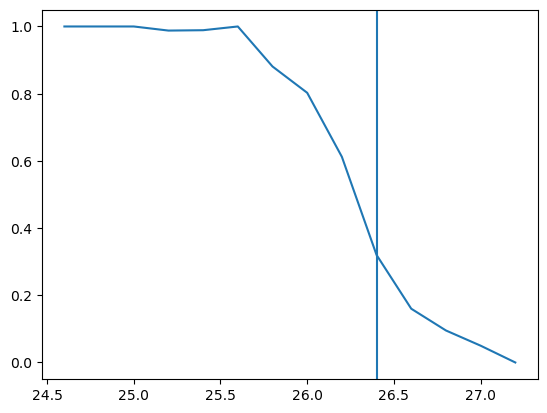

In [1010]:
comp_bins = np.arange(17.5, 29.6, 0.2)
plt.plot(*_binned_stat(tab['mag_in'], tab['recovered'], comp_bins, stat='mean'))
plt.axvline(26.4)

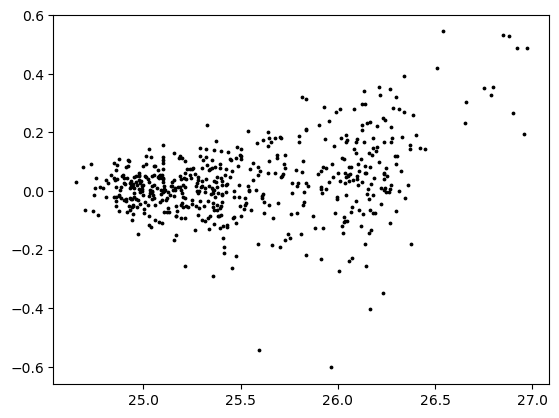

In [1013]:
delta_m = tab['mag_in'] - tab['mag_out']
plt.scatter(tab['mag_in'], delta_m, s=3, c='k')

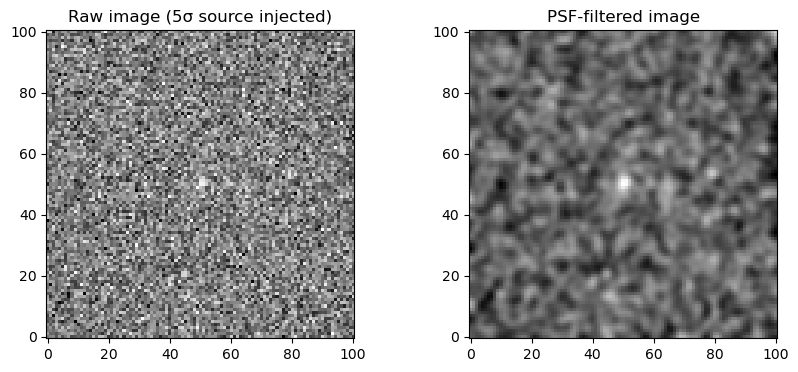

In [811]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Image parameters
np.random.seed(41)
ny, nx = 101, 101
sigma_pix = 1.0          # per-pixel noise (arbitrary units)
fwhm = 3.0               # PSF FWHM in pixels
sigma_psf = fwhm / 2.355

# Noise image
img = np.random.normal(0.0, sigma_pix, size=(ny, nx))

# Effective number of pixels for a Gaussian PSF
N_eff = 4 * np.pi * sigma_psf**2
sigma_flux = sigma_pix * np.sqrt(N_eff)

# Define a 5-sigma source in total flux
flux_5sigma = 5.0 * sigma_flux

# Create PSF-normalized point source
yy, xx = np.mgrid[:ny, :nx]
yc, xc = ny//2, nx//2
psf = np.exp(-((xx-xc)**2 + (yy-yc)**2) / (2*sigma_psf**2))
psf /= psf.sum()

img += flux_5sigma * psf

# Smooth with matched filter (PSF)
img_filt = gaussian_filter(img, sigma_psf)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, origin='lower', cmap='gray', vmin=-3, vmax=3)
axes[0].set_title("Raw image (5σ source injected)")
axes[1].imshow(img_filt, origin='lower', cmap='gray')
axes[1].set_title("PSF-filtered image")
plt.show()


In [814]:
import numpy as np
from astropy.table import Table
from astropy.modeling.fitting import LevMarLSQFitter
from photutils.psf import IntegratedGaussianPRF, PSFPhotometry

# Build a simple PSF/PRF model. For your simulation, sigma_psf should match injection.
# If you injected a Gaussian PSF with sigma_psf = fwhm/2.355, use the same here.
# prf = IntegratedGaussianPRF(sigma=sigma_psf)
psf_model = ImagePSF(psf)

# Fix centroid parameters for forced photometry
psf_model.x_0.fixed = True
psf_model.y_0.fixed = True

# Provide an error image (per-pixel 1σ). For constant Gaussian noise:
error = np.ones_like(img) * sigma_pix

# Initial guess table (forced position, flux guess)
init = Table()
init["x_0"] = [xc]
init["y_0"] = [yc]
init["flux_0"] = [np.max(img) * 2*np.pi*sigma_psf**2]  # crude guess; anything reasonable is fine

phot = PSFPhotometry(
    psf_model=psf_model,
    fitter=LevMarLSQFitter(),
    fit_shape=(11, 11),      # size of fitting box; must cover the PSF core
    aperture_radius=None     # not needed here
)

result = phot(img, init_params=init, error=error)

# Extract fitted flux and its uncertainty
flux_fit = result["flux_fit"][0]
flux_err = result["flux_err"][0]
snr = flux_fit / flux_err

print(f"flux_fit = {flux_fit:.3f}")
print(f"flux_err = {flux_err:.3f}")
print(f"SNR      = {snr:.2f}")

flux_fit = 27.577
flux_err = 4.532
SNR      = 6.09


In [786]:
temp = run_photometry(img, ImagePSF(psf), fwhm=2, threshold_sigma=3.5)
len(temp)

2

In [792]:
temp[1]['flux_fit']

np.float64(32.08355417050436)

In [791]:
temp[1]['flux_fit']# / temp[1]['flux_err']

np.float64(7.045294394299088)

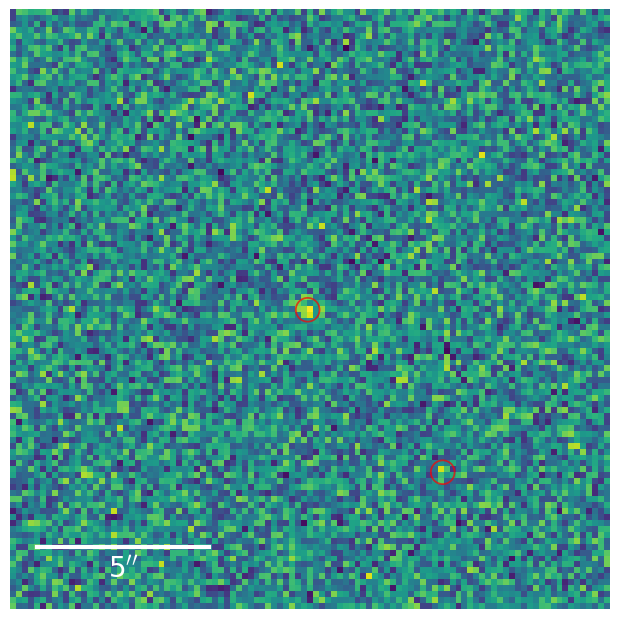

In [787]:
draw_circles(img, temp, colnames=['x_fit', 'y_fit'], circle_size=4)